# KNN = K.NEAREST NEIGBHORS

In [56]:
import pandas as pd
from sklearn.datasets import load_iris

In [57]:
iris = load_iris()

In [58]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [60]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [61]:
df = pd.DataFrame(iris.data,columns=iris.feature_names)

In [62]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [63]:
df["target"] = iris.target

In [64]:
df["target == 1"] = iris.target

In [65]:
df["target == 2"] = iris.target

In [66]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target == 1,target == 2
0,5.1,3.5,1.4,0.2,0,0,0
1,4.9,3.0,1.4,0.2,0,0,0
2,4.7,3.2,1.3,0.2,0,0,0
3,4.6,3.1,1.5,0.2,0,0,0
4,5.0,3.6,1.4,0.2,0,0,0
5,5.4,3.9,1.7,0.4,0,0,0
6,4.6,3.4,1.4,0.3,0,0,0
7,5.0,3.4,1.5,0.2,0,0,0
8,4.4,2.9,1.4,0.2,0,0,0
9,4.9,3.1,1.5,0.1,0,0,0


In [67]:
df["flower_name"] = df.target.apply(lambda x:iris.target_names[x])

In [68]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target == 1,target == 2,flower_name
0,5.1,3.5,1.4,0.2,0,0,0,setosa
1,4.9,3.0,1.4,0.2,0,0,0,setosa
2,4.7,3.2,1.3,0.2,0,0,0,setosa
3,4.6,3.1,1.5,0.2,0,0,0,setosa
4,5.0,3.6,1.4,0.2,0,0,0,setosa
5,5.4,3.9,1.7,0.4,0,0,0,setosa
6,4.6,3.4,1.4,0.3,0,0,0,setosa
7,5.0,3.4,1.5,0.2,0,0,0,setosa
8,4.4,2.9,1.4,0.2,0,0,0,setosa
9,4.9,3.1,1.5,0.1,0,0,0,setosa


In [69]:
df.shape

(150, 8)

In [70]:
df[45:55]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target == 1,target == 2,flower_name
45,4.8,3.0,1.4,0.3,0,0,0,setosa
46,5.1,3.8,1.6,0.2,0,0,0,setosa
47,4.6,3.2,1.4,0.2,0,0,0,setosa
48,5.3,3.7,1.5,0.2,0,0,0,setosa
49,5.0,3.3,1.4,0.2,0,0,0,setosa
50,7.0,3.2,4.7,1.4,1,1,1,versicolor
51,6.4,3.2,4.5,1.5,1,1,1,versicolor
52,6.9,3.1,4.9,1.5,1,1,1,versicolor
53,5.5,2.3,4.0,1.3,1,1,1,versicolor
54,6.5,2.8,4.6,1.5,1,1,1,versicolor


In [71]:
df0 = df[:50]
df1 = df[50:100]
df2 = df[100:]

In [72]:
import matplotlib.pyplot as plt
%matplotlib inline

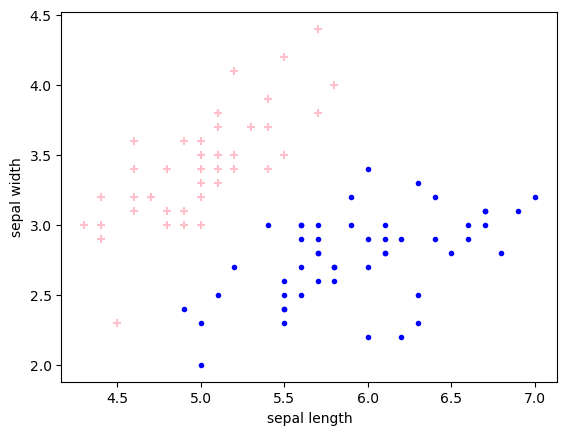

In [73]:
plt.xlabel("sepal length")
plt.ylabel("sepal width")
plt.scatter(df0["sepal length (cm)"],df0["sepal width (cm)"],color = "pink", marker="+")
plt.scatter(df1["sepal length (cm)"],df1["sepal width (cm)"],color = "blue", marker=".")

Text(0, 0.5, 'sepal width (cm)')

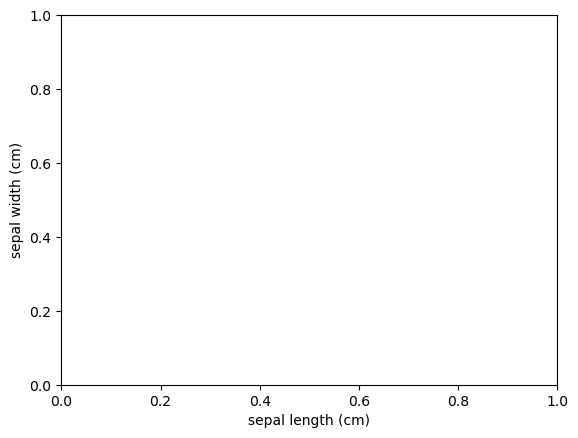

In [74]:
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")



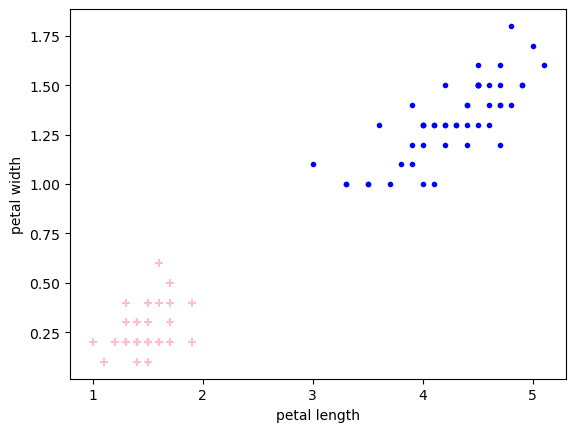

In [75]:
plt.xlabel("petal length")
plt.ylabel("petal width")
plt.scatter(df0["petal length (cm)"],df0["petal width (cm)"],color = "pink", marker="+")
plt.scatter(df1["petal length (cm)"],df1["petal width (cm)"],color = "blue", marker=".")

Text(0, 0.5, 'petal width (cm')

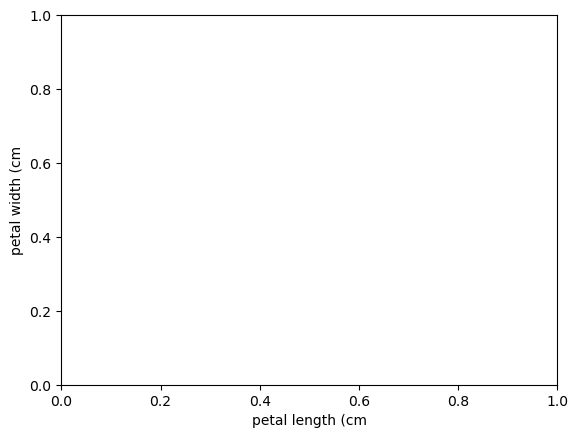

In [76]:
plt.xlabel("petal length (cm")
plt.ylabel("petal width (cm")



# Train test split

In [114]:
from sklearn.model_selection import train_test_split

In [115]:
x = df.drop(["target","flower_name"],axis = "columns")
y = df.target

In [116]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [117]:
len(x_train)

120

In [118]:
len(x_test)

30

# Create knn

In [119]:
from sklearn.neighbors import KNeighborsClassifier

In [126]:
knn = KNeighborsClassifier(n_neighbors=3)


In [127]:
knn.fit(x_train, y_train)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [128]:
knn.score(x_test, y_test)

1.0

In [132]:
from sklearn.metrics import confusion_matrix
y_pred = knn.predict(x_test)
cm = confusion_matrix(y_test,y_pred)

In [133]:
cm

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

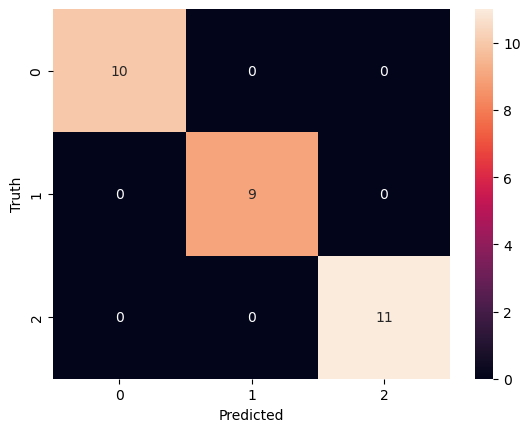

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()